# **Brain Tumor Image Classifier**

#*Work in progress — exploring how models interpret visual signal.*



# ANN vs Transfer Learning (VGG16) – Understanding How Models See

This notebook is part of my effort to break down how neural networks process visual data.

# I’m not just training models — I’m trying to understand how to isolatee what matters.

Core question:
When a model looks at an image…  
→ what is it actually *locking onto*?

This walks through:
- A basic ANN approach
- Transfer learning using VGG16
- Observations on how features emerge and dominate

Work in progress — this will evolve.



## What I care about isn’t just accuracy — it’s understanding how the model decides what matters.

## Phase 1: Baseline (ANN)

Before jumping into complex architectures, I wanted a baseline.

Question:
How far can a simple ANN get when dealing with image data?

Expectation:
- Limited spatial awareness
- Likely poor performance compared to CNN-based models

This gives me a reference point before introducing feature extraction.

## **Installing and Importing the Necessary Libraries**

In [ ]:
import sys
!{sys.executable} -m pip install numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 tensorflow==2.18.0 ml_dtypes>=0.5.0 -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.18.0 which is incompatible.
jax 0.7.2 requires ml_dtypes>=0.5.0, but you have ml-dtypes 0.4.1 which is incompatible.
tensorstore 0.1.82 requires ml_dtypes>=0.5.0, but you have ml-dtypes 0.4.1 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.18.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.18.0 which is incompatible.
jaxlib 0.7.2 requires ml_dtypes>=0.5.0, but you have ml-dtypes 0.4.1 which is incompatible.


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
!pip install -U "ml_dtypes>=0.5.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 46.2 MB/s eta 0:00:00
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.18.0 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.18.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.18.0 which is incompatible.


In [ ]:
# Library for creating data paths
import os

# Library for randomly selecting data points
import random

# Library for performing numerical computations
import numpy as np

# Library for creating and showing plots
import matplotlib.pyplot as plt

# Library for reading and showing images
import matplotlib.image as mpimg


# Importing all the required sub-modules from Keras
import tensorflow
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout

Mounting the drive to load the dataset

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


We have stored the images in a structured folder, and below we create the data paths to load images from those folders. This is required so that we can extract images in an auto-labelled fashion using Keras **flow_from_directory**.

In [ ]:
# Parent directory where images are stored in drive
parent_dir = '/content/drive/MyDrive/brain_tumor'

# Path to the training and testing datasets within the parent directory
train_dir = os.path.join(parent_dir, 'Training')
validation_dir = os.path.join(parent_dir, 'Testing')

# Directory with our training pictures
train_pituitary_dir = os.path.join(train_dir, 'pituitary_tumor')
train_no_dir = os.path.join(train_dir, 'no_tumor')

# Directory with our testing pictures
validation_pituitary_dir = os.path.join(validation_dir, 'pituitary_tumor')
validation_no_dir = os.path.join(validation_dir, 'no_tumor')

In [ ]:
import os

# List contents of MyDrive to help locate the dataset
print("Contents of /content/drive/MyDrive/")
print(os.listdir('/content/drive/MyDrive/'))

# If your brain_tumor folder is nested within another folder in MyDrive, you might need to adjust this.
# For example, if it's in 'Colab Notebooks/brain_tumor', then parent_dir would be '/content/drive/MyDrive/Colab Notebooks/brain_tumor'
# Please modify the 'parent_dir' variable in the next cell after identifying the correct path.

Contents of /content/drive/MyDrive/
['glove.6B.100d.txt', 'PA_unknown-serial_ts_111.3_20250114_1158 (1).tar.gz', 'PA_unknown-serial_ts_111.3_20250114_1158.tar.gz', 'FGT_AP_for_PCA.zip', 'Cloudera', 'Colab Notebooks', 'My_Class_Files', 'My_Class_Files.npy', 'multiple_files.npz', 'boxplot.png', 'skew_box.png', 'Line_plot.png', 'Melbourne_Housing.csv', 'box-plot-2.png', 'Admission_Predict (1).csv', 'Automobile.csv', 'Titanic+Data+Set.csv', 'Placement_Data.csv', 'Uber_Data.csv', 'movie.csv', 'user.csv', 'ratings.csv', 'Product_Reviews.csv', 'InteractiveSheet_2025-10-17_16_45_56.gsheet', 'InteractiveSheet_2025-10-17_16_46_25.gsheet', 'movie_reviews.csv', 'InteractiveSheet_2025-10-22_23_31_12.gsheet', 'InteractiveSheet_2025-10-22_23_32_07.gsheet', 'InteractiveSheet_2025-10-22_23_32_30.gsheet', 'InteractiveSheet_2025-10-22_23_35_43.gsheet', 'InteractiveSheet_2025-10-22_23_46_22.gsheet', 'InteractiveSheet_2025-10-22_23_46_33.gsheet', 'PTPM TN.docx', 'Google_Cloud_Certifications_Roadmap_RobertM

Based on the output above, please update the `parent_dir` variable below to the correct path where your `brain_tumor` folder is located within `MyDrive`. For example, if `brain_tumor` is directly under `MyDrive`, keep it as it is. If it's under a folder called `datasets` inside `MyDrive`, it would be `/content/drive/MyDrive/datasets/brain_tumor`.

In [ ]:
# Update this path based on your actual Google Drive structure
parent_dir = '/content/drive/MyDrive/brain_tumor' # <-- MODIFY THIS LINE IF NEEDED

# Path to the training and testing datasets within the parent directory
train_dir = os.path.join(parent_dir, 'Training')
validation_dir = os.path.join(parent_dir, 'Testing')

# Directory with our training pictures
train_pituitary_dir = os.path.join(train_dir, 'pituitary_tumor')
train_no_dir = os.path.join(train_dir, 'no_tumor')

# Directory with our testing pictures
validation_pituitary_dir = os.path.join(validation_dir, 'pituitary_tumor')
validation_no_dir = os.path.join(validation_dir, 'no_tumor')

print(f"Updated parent_dir: {parent_dir}")
print(f"Updated train_dir: {train_dir}")
print(f"Updated validation_dir: {validation_dir}")

Updated parent_dir: /content/drive/MyDrive/brain_tumor
Updated train_dir: /content/drive/MyDrive/brain_tumor/Training
Updated validation_dir: /content/drive/MyDrive/brain_tumor/Testing


### **Verifying `brain_tumor` Folder Path**

Since the `brain_tumor` folder was not found directly in `MyDrive`, let's try to locate it within common subdirectories. The following code will search for the folder and print its full path if found. You can then use this path to update the `parent_dir` variable in the previous cell (`29f2c0c3`).

In [ ]:
import os

def find_directory(start_path, dir_name):
    """Recursively searches for a directory starting from start_path."""
    for root, dirs, files in os.walk(start_path):
        if dir_name in dirs:
            return os.path.join(root, dir_name)
    return None

# Define the directory we are looking for
target_dir_name = 'brain_tumor'

# Define potential base paths to search
search_paths = [
    '/content/drive/MyDrive',
    '/content/drive/MyDrive/Colab Notebooks',
    # Add any other common directories where you might have saved it
]

found_path = None
for path in search_paths:
    print(f"Searching for '{target_dir_name}' in '{path}'...")
    found_path = find_directory(path, target_dir_name)
    if found_path:
        break

if found_path:
    print(f"\nSUCCESS: Found '{target_dir_name}' at: {found_path}")
    print(f"Please update `parent_dir` in cell `29f2c0c3` to: `parent_dir = '{found_path}'`")
else:
    print(f"\nERROR: '{target_dir_name}' not found in any searched locations.")
    print("Please ensure the 'brain_tumor' folder is uploaded to your Google Drive and its path is correct.")


Searching for 'brain_tumor' in '/content/drive/MyDrive'...

SUCCESS: Found 'brain_tumor' at: /content/drive/MyDrive/brain_tumor
Please update `parent_dir` in cell `29f2c0c3` to: `parent_dir = '/content/drive/MyDrive/brain_tumor'`


### **Manual Path Verification**

If the automatic search didn't find your `brain_tumor` folder, you might need to manually specify a potential path. Use the cell below to enter a path you suspect might contain the `brain_tumor` folder. The code will then check if the `Training` and `Testing` subdirectories, as well as their respective 'pituitary_tumor' and 'no_tumor' folders, exist within your provided path. This should help you confirm the correct `parent_dir`.

In [ ]:
import os

def verify_dataset_structure(base_path):
    print(f"Verifying structure under: {base_path}")

    train_dir_check = os.path.join(base_path, 'Training')
    validation_dir_check = os.path.join(base_path, 'Testing')

    if not os.path.isdir(train_dir_check):
        print(f"  ERROR: Training directory not found: {train_dir_check}")
        return False
    if not os.path.isdir(validation_dir_check):
        print(f"  ERROR: Testing directory not found: {validation_dir_check}")
        return False

    print(f"  SUCCESS: Found Training directory: {train_dir_check}")
    print(f"  SUCCESS: Found Testing directory: {validation_dir_check}")

    # Further check subdirectories within Training and Testing
    subdirs_to_check = {
        'Training': ['pituitary_tumor', 'no_tumor'],
        'Testing': ['pituitary_tumor', 'no_tumor']
    }

    all_subdirs_found = True
    for parent, subdirs in subdirs_to_check.items():
        current_base = os.path.join(base_path, parent)
        for subdir in subdirs:
            full_path = os.path.join(current_base, subdir)
            if not os.path.isdir(full_path):
                print(f"  ERROR: Subdirectory not found: {full_path}")
                all_subdirs_found = False
            else:
                print(f"  SUCCESS: Found subdirectory: {full_path}")

    # Add a check to list files in the prospective path to help with debugging
    print(f"\n--- Contents of {base_path} ---")
    try:
        for item in os.listdir(base_path):
            print(f"- {item}")
    except FileNotFoundError:
        print(f"  Directory not found: {base_path}")
    except Exception as e:
        print(f"  Could not list contents: {e}")
    print("------------------------------")

    return all_subdirs_found

# --- USER INPUT REQUIRED ---
# Enter the path you *think* is the parent of 'brain_tumor' folder.
# For example, if 'brain_tumor' is in '/content/drive/MyDrive/MyData/', then set this to '/content/drive/MyDrive/MyData/brain_tumor'.
# If 'brain_tumor' is directly in MyDrive, then it should be '/content/drive/MyDrive/brain_tumor'

# Update this variable with your best guess for the 'brain_tumor' folder's path
prospective_brain_tumor_path = '/content/drive/MyDrive/brain_tumor' # <--- MODIFY THIS LINE

if verify_dataset_structure(prospective_brain_tumor_path):
    print(f"\nGreat! The dataset structure seems correct at: {prospective_brain_tumor_path}")
    print(f"Please update `parent_dir` in cell `29f2c0c3` to: `parent_dir = '{prospective_brain_tumor_path}'`")
    print("Then re-run cell `29f2c0c3` and all subsequent cells.")
else:
    print(f"\nThe dataset structure was NOT found at: {prospective_brain_tumor_path}")
    print("Please adjust `prospective_brain_tumor_path` and try again, or manually check your Google Drive.")

Verifying structure under: /content/drive/MyDrive/brain_tumor
  SUCCESS: Found Training directory: /content/drive/MyDrive/brain_tumor/Training
  SUCCESS: Found Testing directory: /content/drive/MyDrive/brain_tumor/Testing
  SUCCESS: Found subdirectory: /content/drive/MyDrive/brain_tumor/Training/pituitary_tumor
  SUCCESS: Found subdirectory: /content/drive/MyDrive/brain_tumor/Training/no_tumor
  SUCCESS: Found subdirectory: /content/drive/MyDrive/brain_tumor/Testing/pituitary_tumor
  SUCCESS: Found subdirectory: /content/drive/MyDrive/brain_tumor/Testing/no_tumor

--- Contents of /content/drive/MyDrive/brain_tumor ---
- .DS_Store
- Training
- Testing
------------------------------

Great! The dataset structure seems correct at: /content/drive/MyDrive/brain_tumor
Please update `parent_dir` in cell `29f2c0c3` to: `parent_dir = '/content/drive/MyDrive/brain_tumor'`
Then re-run cell `29f2c0c3` and all subsequent cells.


## **Visualizing a few images**

Before we move ahead and perform data augmentation, let's randomly check out some of the images and see what they look like:

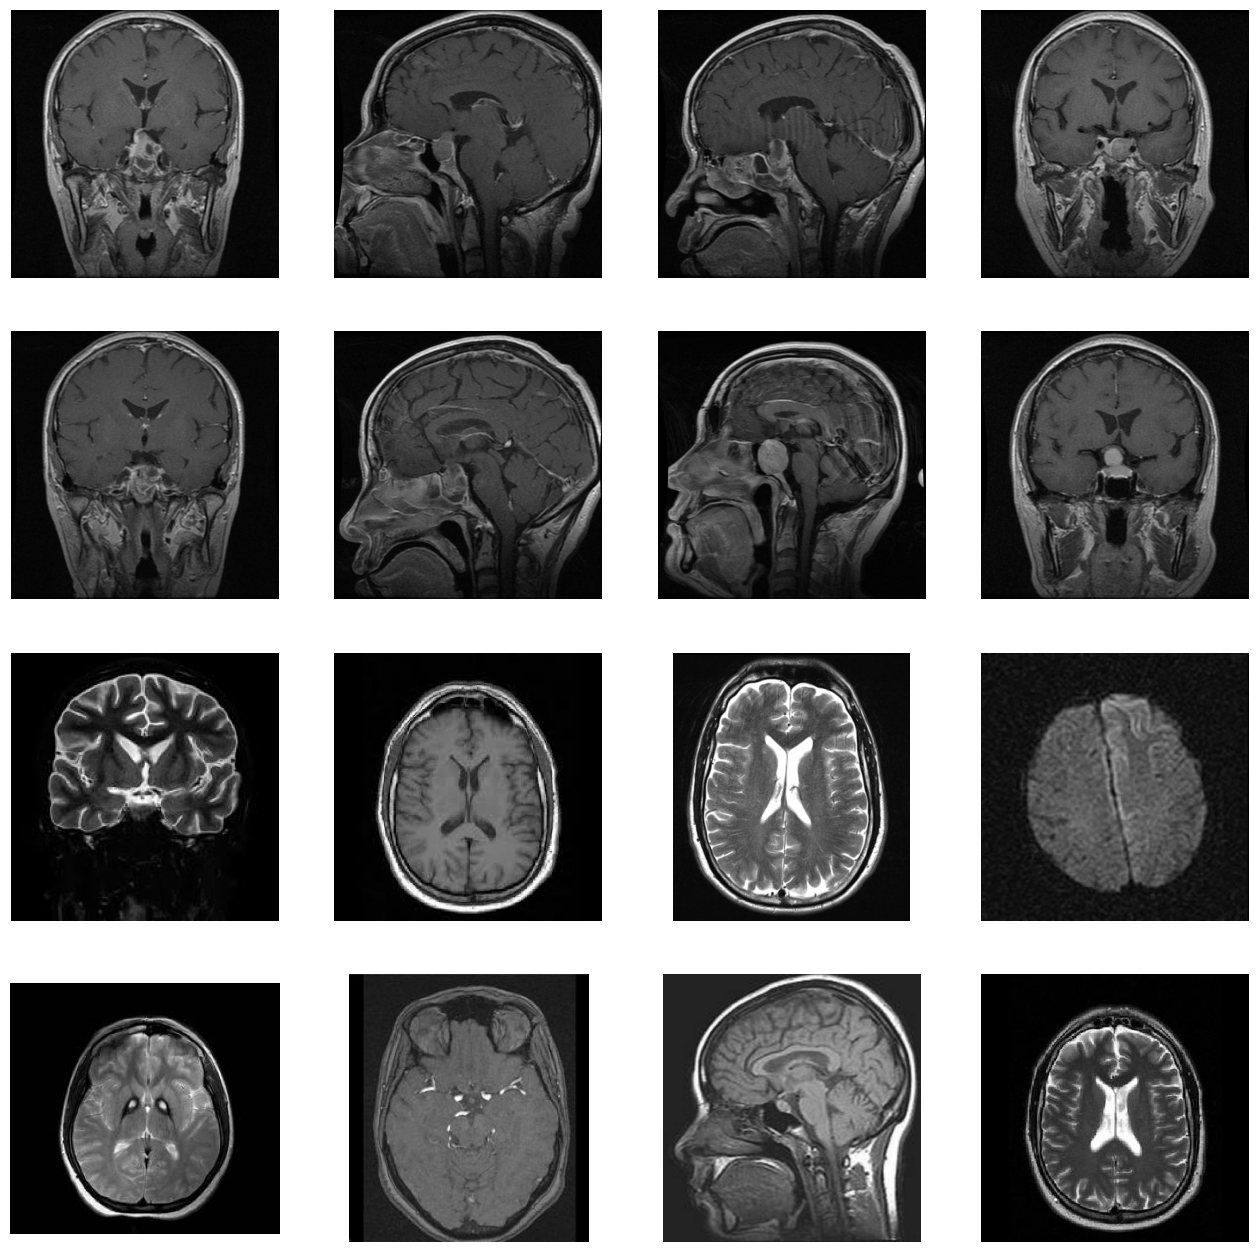

In [ ]:
train_pituitary_file_names = os.listdir(train_pituitary_dir)
train_no_file_names = os.listdir(train_no_dir)

fig = plt.figure(figsize=(16, 8))
fig.set_size_inches(16, 16)

pituitary_img_paths = [os.path.join(train_pituitary_dir, file_name) for file_name in train_pituitary_file_names[:8]]
no_img_paths = [os.path.join(train_no_dir, file_name) for file_name in train_no_file_names[:8]]

for i, img_path in enumerate(pituitary_img_paths + no_img_paths):
    ax = plt.subplot(4, 4, i + 1)
    ax.axis('Off')

    img = mpimg.imread(img_path)
    plt.imshow(img)

plt.show()

As we can see, the images are quite different in size from each other.

This represents a problem, as most CNN architectures, including the pre-built model architectures that we will use for Transfer Learning, **expect all the images to have the same size.**

So we need to crop these images from the center to make sure they all have the same size. We can do this automatically while performing Data Augmentation, as shown below.

## **Data Augmentation**

In most real-life case studies, it is generally difficult to collect lots of images and then train CNNs. In that case, one idea we can take advantage of is Data Augmentation. CNNs have the property of **translational invariance**, i.e., they can recognize an object as an object, even when its appearance varies translationally in some way. Taking this property into consideration, we can augment the images using the following techniques:

**1. Horizontal Flip** (should be set to True/False) <br>
**2. Vertical Flip** (should be set to True/False) <br>
**3. Height Shift** (should be between 0 and 1) <br>
**4. Width Shift** (should be between 0 and 1) <br>
**5. Rotation** (should be between 0 and 180) <br>
**6. Shear** (should be between 0 and 1) <br>
**7. Zoom** (should be between 0 and 1) etc. <br>

Remember ***not to use data augmentation in the validation/test data set***.

Also, as mentioned above, we need to have images of the same size. So below,we resize the images by using the parameter **target_size**. Here we are resizing it to **224 x 224**, as we will be using the **VGG16** model for Transfer Learning, which takes image inputs as **224 x 224**.

As this is a binary classification problem, we will need class labels. This is directly handled by the **flow_from_directory** function. It will take the images from the folder inside our specified directory, and the images from one folder will belong to same class.

As the train directory has 2 folders pituitary_tumor and no_tumor, it will read the directory and each folder will be considered a separate class. We specify **class_model = 'binary'** as this is a binary classification problem.

As the folders inside the directory will be read in an alphabetical order, the no_tumor folder will be given a label 0, and pituitary_tumor will be label 1.

In [ ]:
# All images to be rescaled by 1/255.
train_datagen = ImageDataGenerator(rescale=1. / 255.0,
                              horizontal_flip = True,
                              vertical_flip = False,
                              height_shift_range= 0.1,
                              width_shift_range=0.1,
                              rotation_range=20,
                              shear_range = 0.1,
                              zoom_range=0.1)
test_datagen  = ImageDataGenerator(rescale = 1.0/255.)

# Flowing training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow_from_directory(train_dir,
                                                    batch_size=20,
                                                    class_mode='binary',
                                                    target_size=(224, 224))

# Flowing testing images in batches of 20 using test_datagen generator
validation_generator =  test_datagen.flow_from_directory(validation_dir,
                                                         batch_size=20,
                                                         class_mode  = 'binary',
                                                         target_size = (224, 224))

Found 830 images belonging to 2 classes.
Found 170 images belonging to 2 classes.


Let's look at some examples of our augmented training data.

This is helpful for understanding the extent to which data is being manipulated prior to training, and can be compared with how the raw data looks prior to data augmentation.

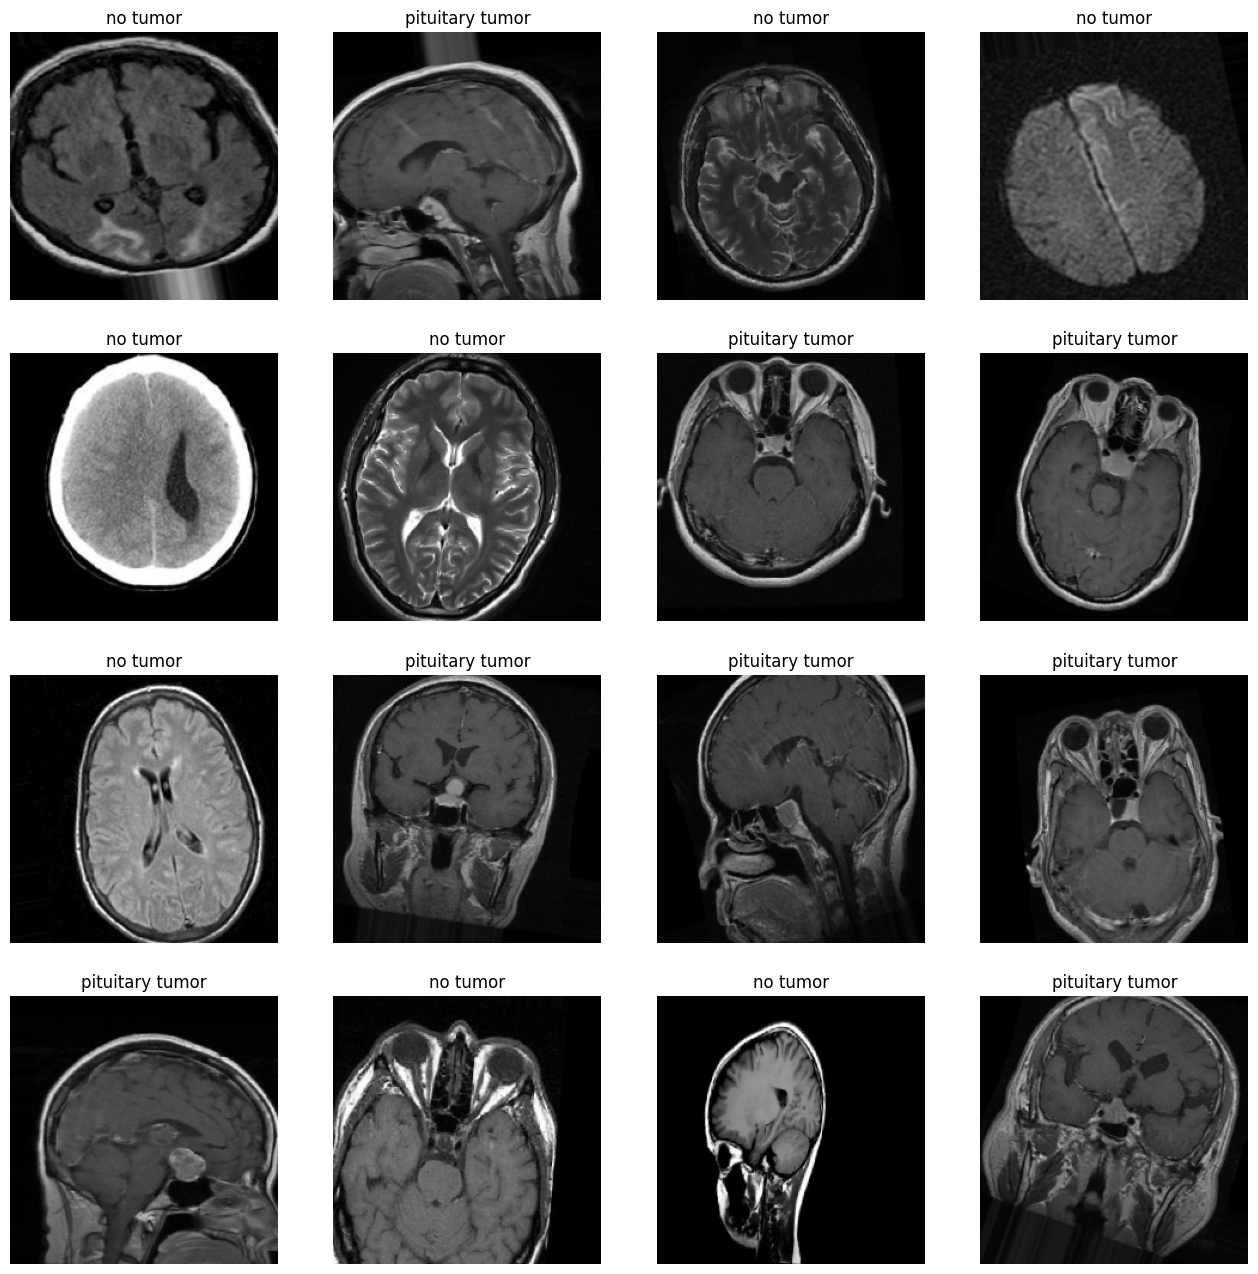

In [ ]:
images, labels = next(train_generator)
fig, axes = plt.subplots(4, 4, figsize = (16, 8))
fig.set_size_inches(16, 16)
for (image, label, ax) in zip(images, labels, axes.flatten()):
    ax.imshow(image)
    if label == 1:
        ax.set_title('pituitary tumor')
    else:
        ax.set_title('no tumor')
    ax.axis('off')

## **CNN Model Building**

Once the data is augmented and cropped to have the same size, we are now ready to build a first baseline CNN model to classify no_tumor vs pituitary_tumor.

When building our custom model, we have used Batch Normalization and Dropout layers as regularization techniques to prevent overfitting.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout

cnn_model = Sequential()
cnn_model.add(Conv2D(64, (3,3), activation='relu', input_shape=(224, 224, 3), padding = 'same'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(BatchNormalization())
cnn_model.add(Conv2D(32, (3,3), activation='relu', padding = 'same'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(BatchNormalization())
cnn_model.add(Conv2D(32, (3,3), activation='relu', padding = 'same'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Conv2D(16, (3,3), activation='relu', padding = 'same'))
cnn_model.add(Flatten())
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dropout(0.4)) # Modified dropout rate to 0.4
cnn_model.add(Dense(32, activation='relu'))
cnn_model.add(Dropout(0.4)) # Modified dropout rate to 0.4
cnn_model.add(Dense(32, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_model.compile(loss="binary_crossentropy", optimizer="adam", metrics = ['accuracy'])
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 840,561 (3.21 MB)

 Trainable params: 840,369 (3.21 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Pulling a single large batch of random testing data for testing after each epoch
testX, testY = next(validation_generator)

In [ ]:
model_history = cnn_model.fit(train_generator,
                              validation_data=(testX, testY),
                              epochs=10)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 25s 383ms/step - accuracy: 0.5229 - loss: 0.7480 - val_accuracy: 0.4000 - val_loss: 0.6930
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 267ms/step - accuracy: 0.7602 - loss: 0.5551 - val_accuracy: 0.3500 - val_loss: 0.7197
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 262ms/step - accuracy: 0.8301 - loss: 0.4819 - val_accuracy: 0.3500 - val_loss: 0.7753
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 266ms/step - accuracy: 0.8169 - loss: 0.4698 - val_accuracy: 0.3500 - val_loss: 0.7856
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 268ms/step - accuracy: 0.8386 - loss: 0.3956 - val_accuracy: 0.5500 - val_loss: 0.8756
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 269ms/step - accuracy: 0.8651 - loss: 0.3608 - val_accuracy: 0.5000 - val_loss: 0.9106
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 267ms/step - accuracy: 0.9012 - loss: 0.2769 - val_accuracy: 0.4500 - val_loss: 1.0138
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 263ms/step - accuracy: 0.8843 - loss: 0.3222 - val_accu

In [ ]:
# Evaluating on the Test dataset
cnn_model.evaluate(validation_generator)

9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.5059 - loss: 1.3894


[1.3894307613372803, 0.5058823823928833]

### Interpretation

The ANN treats the image as flattened data.

There’s no sense of:
- spatial structure
- edges
- shapes

It’s trying to learn vision without actually “seeing.”

That limitation shows up quickly in performance.

## This becomes the baseline limitation:

The model sees data —  
but it doesn’t understand structure.

### **Findings**

- Our model had 840,369 trainable parameters.
- After running 10 epochs, we were able to achieve a training accuracy of ~95% and a testing accuracy of ~72%.
- Even after using Data Augmentation, Batch Normalization and the Dropout Layers, the model seems to have highly overfit on the training dataset and is performing somewhat poorly.

## So instead of teaching a model to see from scratch —  
## I decided to borrow vision.
## More Precisely the well known VGG16 Model:
  VGG16 is a landmark convolutional neural network (CNN) architecture that played a crucial role in advancing deep learning for computer vision. Developed by the Visual Geometry Group at the University of Oxford and introduced in 2014, it is celebrated for its simplicity and uniform, deep structure

##

## Phase 2: Transfer Learning (VGG16)

At this point, it becomes clear:

Training from scratch isn’t just hard —  
it’s inefficient without massive data and compute.

So instead of building vision from zero,
I’m leveraging a model that already understands patterns:
VGG16.

Key shift:
- From *learning features* → to *using learned features*

Now the question becomes:
What happens when I plug into an already-trained visual system?

### What Changed

This is no longer about learning from scratch.

The model already knows:
- edges
- textures
- shapes

I’m plugging into an existing visual system.

So instead of asking:
“How do I train a model?”

I’m asking:
“What does this model already know — and how do I use it?”

## **Model Building using Transfer Learning: VGG 16**

- Now, let's try again, but this time, using the idea of **Transfer Learning**. We will be loading a pre-built architecture - **VGG16**, which was trained on the ImageNet dataset and finished runner-up in the ImageNet competition in 2014. Below is a schematic of the VGG16 model.

- For training VGG16, we will directly use the convolutional and pooling layers and freeze their weights i.e. no training will be done on them. We will remove the already-present fully-connected layers and add our own fully-connected layers for this binary classification task.


![vgg16](https://upload.wikimedia.org/wikipedia/commons/2/24/VGG16.png)

In [ ]:
# Summary of the whole model
model = VGG16(weights='imagenet')
model.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Getting only the conv layers for transfer learning.
transfer_layer = model.get_layer('block5_pool')
vgg_model = Model(inputs=model.input, outputs=transfer_layer.output)

In [ ]:
vgg_model.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

- To remove the fully-connected layers of the imported pre-trained model, while calling it from Keras we can also specify an additonal keyword argument that is **include_top**.

- **If we specify include_top = False, then the model will be imported without the fully-connected layers.** Here we won't have to do the above steps of getting the last convolutional layer and creating a separate model.

- If we are specifying include_top = False, we will also have to specify our input image shape.

- Keras has this keyword argument as generally while importing a pre-trained CNN model, we don't require the fully-connected layers and we train our own fully-connected layers for our task.

In [ ]:
vgg_model = VGG16(weights='imagenet', include_top = False, input_shape = (224,224,3))
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

In [ ]:
for layer in vgg_model.layers:
    print(layer.name, layer.trainable)

input_layer_2 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 False
block5_conv2 False
block5_conv3 False
block5_pool False


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

new_model = Sequential()

# Add the convolutional base
new_model.add(vgg_model)

# Replace Flatten with GAP
new_model.add(GlobalAveragePooling2D())

# Classifier head
new_model.add(Dense(32, activation='relu'))
new_model.add(Dropout(0.4))
new_model.add(Dense(64, activation='relu'))
new_model.add(Dropout(0.4))
new_model.add(Dense(1, activation='sigmoid'))

In [ ]:
for layer in vgg_model.layers:
    if layer.name.startswith('block5'):
        layer.trainable = False

In [ ]:
new_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
new_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,281 (56.20 MB)

 Trainable params: 18,593 (72.63 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
fine_tune_history = new_model.fit(
    train_generator,
    validation_data=(testX, testY),
    epochs=10
)

new_model.evaluate(validation_generator)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 279ms/step - accuracy: 0.9542 - loss: 0.1501 - val_accuracy: 0.9000 - val_loss: 0.2595
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 274ms/step - accuracy: 0.9494 - loss: 0.1526 - val_accuracy: 0.9000 - val_loss: 0.2584
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 274ms/step - accuracy: 0.9530 - loss: 0.1131 - val_accuracy: 0.8500 - val_loss: 0.2527
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 279ms/step - accuracy: 0.9639 - loss: 0.1126 - val_accuracy: 0.8500 - val_loss: 0.2846
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 283ms/step - accuracy: 0.9639 - loss: 0.1140 - val_accuracy: 0.9000 - val_loss: 0.3202
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 276ms/step - accuracy: 0.9687 - loss: 0.0811 - val_accuracy: 0.9000 - val_loss: 0.2676
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 276ms/step - accuracy: 0.9735 - loss: 0.0873 - val_accuracy: 0.9000 - val_loss: 0.2846
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 280ms/step - accuracy: 0.9675 - loss: 0.1036 - val_accu

[0.49160483479499817, 0.8352941274642944]

In [ ]:
## Fitting the VGG model
new_model_history = new_model.fit(train_generator,
                                  validation_data=(testX, testY),
                                  epochs=10)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 276ms/step - accuracy: 0.9699 - loss: 0.0840 - val_accuracy: 0.9000 - val_loss: 0.4331
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 281ms/step - accuracy: 0.9687 - loss: 0.0929 - val_accuracy: 0.9000 - val_loss: 0.4192
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 270ms/step - accuracy: 0.9723 - loss: 0.0839 - val_accuracy: 0.9000 - val_loss: 0.3323
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 279ms/step - accuracy: 0.9783 - loss: 0.0750 - val_accuracy: 0.9000 - val_loss: 0.3250
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 280ms/step - accuracy: 0.9723 - loss: 0.0688 - val_accuracy: 0.9000 - val_loss: 0.3077
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 277ms/step - accuracy: 0.9759 - loss: 0.0780 - val_accuracy: 0.9000 - val_loss: 0.3221
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 274ms/step - accuracy: 0.9771 - loss: 0.0678 - val_accuracy: 0.9000 - val_loss: 0.4113
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 273ms/step - accuracy: 0.9771 - loss: 0.0682 - val_accu

In [ ]:
# Evaluating on the Test set
new_model.evaluate(validation_generator)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.8176 - loss: 0.8192


[0.8192435503005981, 0.8176470398902893]

In [ ]:
# Function to plot loss, val_loss,
def plot_history(history):
    N = len(history.history["accuracy"])
    plt.figure()
    plt.plot(np.arange(0, N), history.history["accuracy"], label="train_accuracy")
    plt.plot(np.arange(0, N), history.history["val_accuracy"], label="val_accuracy")
    plt.title("Training accuracy Dataset")
    plt.xlabel("Epoch #")
    plt.ylabel("accuracy")
    plt.legend(loc="upper right")

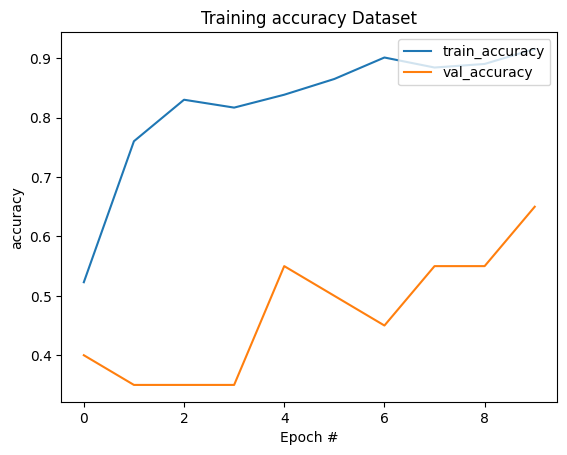

In [ ]:
# Plotting the loss vs epoch curve for the basic CNN model without Transfer Learning
plot_history(model_history)

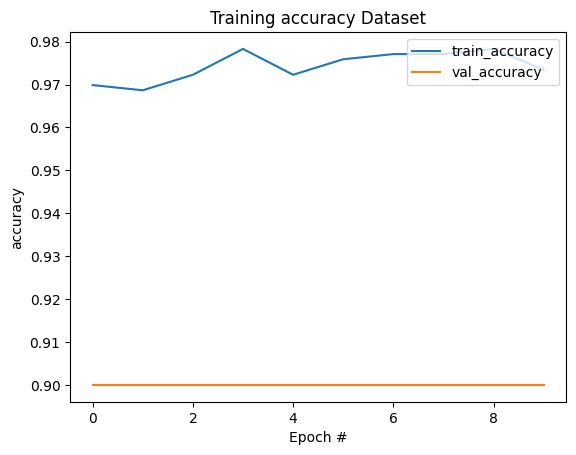

In [ ]:
# Plotting the loss vs epoch curve for the Transfer Learning model
plot_history(new_model_history)

### Findings

- Our model has 803,937 Trainable parameters.
- After running 5 epochs we were able to achieve a training accuracy of ~98% and a validation accuracy of ~ 91%.

### Observation: Not All Features Are Equal

Some features dominate the model’s decisions.

When that happens:
- other features have minimal impact
- learning becomes skewed
- the model can over-rely on a narrow signal

This changed how I think about model behavior.

It’s not just learning —  
it’s **prioritizing**.

### Mental Model

This feels like signal processing.

- Raw image = noisy signal
- Convolutions = filters tuning into patterns
- Pooling = removing noise

You’re not losing information —  
you’re isolating what matters.

### What I will Explore Next

- Visualizing intermediate feature maps
- Identifying which filters activate most strongly
- Testing what happens when dominant features are reduced

Goal:
Understand not just *what* the model predicts —  
but *why those signals win*

## Takeaways

- ANN struggles with raw image understanding
- Transfer learning dramatically improves performance
- Pretrained models act as powerful feature extractors

But more importantly:

This isn’t just about images.

It’s about:
- Signal vs noise
- Feature dominance
- What a system chooses to pay attention to

That pattern shows up everywhere.

## Final Thought

This isn’t just about computer vision.

It’s about how systems filter noise, amplify signal,  
and ultimately decide what matters.